In [3]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sqlalchemy import create_engine

## Competition challenge
### Level 1
Explore and summarise the dataset to understand its structure and key statistics:
1. How many records are in the dataset, and what is the range of years covered?
2. What is the average salary (in USD) for Data Scientists and Data Engineers? Which role earns more on average?
3. How many full-time employees based in the US work 100% remotely?



💾 The data
- The data comes from a survey hosted by an HR consultancy, available in 'salaries.csv'.

- Each row represents a single employee's salary record for a given year:
-  work_year - The year the salary was paid.
    -  experience_level - Employee experience level:
    -  EN: Entry-level / Junior
    -  MI: Mid-level / Intermediate
    -  SE: Senior / Expert
    -  EX: Executive / Director
- employment_type - Employment type:
    -  PT: Part-time
    -  FT: Full-time
    -  CT: Contract
    -  FL: Freelance
- job_title - The job title during the year.
- salary - Gross salary paid (in local currency).
- salary_currency - Salary currency (ISO 4217 code).
- salary_in_usd - Salary converted to USD using average yearly FX rate.
- employee_residence - Employee's primary country of residence (ISO 3166 code).
- remote_ratio - Percentage of remote work:
- 0: No remote work (<20%)
- 50: Hybrid (50%)
- 100: Fully remote (>80%)
- company_location - Employer's main office location (ISO 3166 code).
- company_size - Company size:
    - S: Small (<50 employees)
    - M: Medium (50–250 employees)
    - L: Large (>250 employees)

In [5]:
#Importing Data
df=pd.read_csv('salaries.csv')
df.head(3)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Developer,168276,USD,168276,US,0,US,M
1,2024,MI,FT,Developer,112184,USD,112184,US,0,US,M
2,2024,EN,FT,Developer,180000,USD,180000,US,0,US,M


In [6]:
#Data Exploration & Cleaning
df.shape


(57194, 11)

In [7]:
#Descriptive statistics
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,57194.000000,5.719400e+04,57194.000000,57194.000000
mean,2023.776305,1.641818e+05,159223.565829,22.211246
std,0.519883,2.060327e+05,72155.164297,41.424262
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.094000e+05,109300.000000,0.000000
50%,2024.000000,1.495520e+05,149040.000000,0.000000
75%,2024.000000,2.000000e+05,200000.000000,0.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [8]:
#Checking for Nulls
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [9]:
#Checking for Duplicates
df.duplicated().sum()


np.int64(29883)

In [10]:
df.columns.tolist()

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size']

In [11]:
#Renaming a column
df.rename(columns={'employment_type':'employment_nature'},inplace=True)

In [12]:
#Exploring the total number of employees per job title
df['job_title'].value_counts()

job_title
Data Scientist               9706
Data Engineer                7970
Data Analyst                 5980
Software Engineer            5817
Machine Learning Engineer    5067
                             ... 
Deep Learning Researcher        1
Principal Data Architect        1
Data Science Tech Lead          1
Marketing Data Engineer         1
Cloud Data Architect            1
Name: count, Length: 253, dtype: int64

In [13]:
#Checking no. of people in every experience level
experience_levelvalue=df['experience_level'].value_counts()

In [14]:
#Work year value distribution
work_yearvalue=df['work_year'].value_counts()

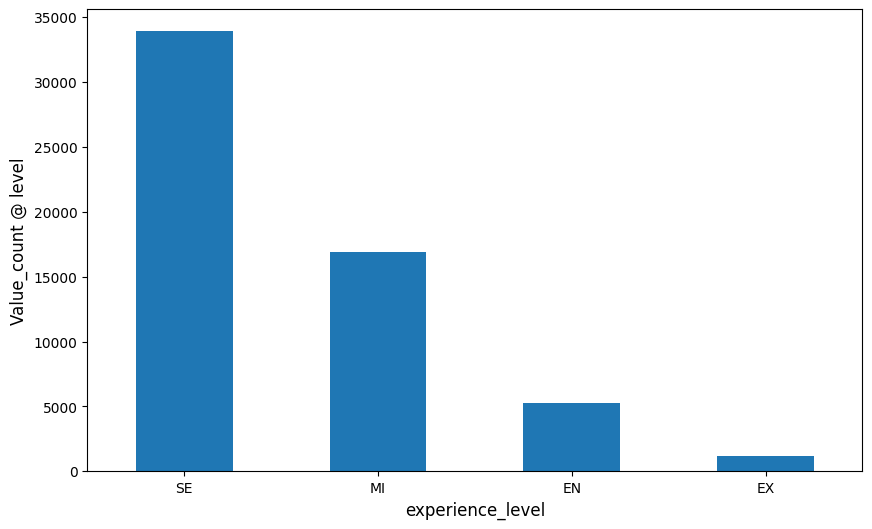

In [15]:
#Plotting Experience Level
plt.figure(figsize=(10,6))
experience_levelvalue.plot(kind='bar',width=0.5)
plt.xlabel('experience_level', fontsize=12)
plt.ylabel('Value_count @ level',fontsize=12)
plt.xticks(rotation=360);

<Axes: ylabel='salary_in_usd'>

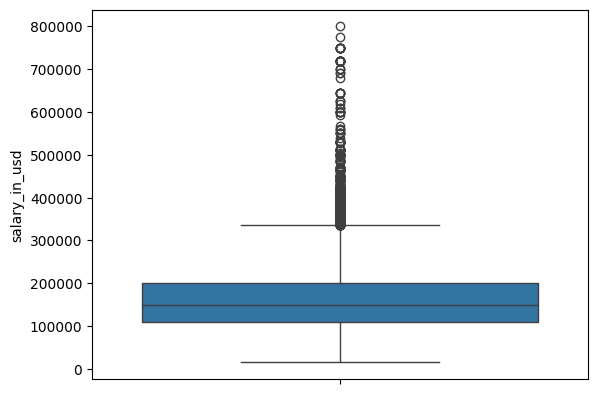

In [16]:
#Checking for Outliers
sns.boxplot(df['salary_in_usd'])

In [17]:
#checking for minimum salary and the respective info in the specified rows
df[df['salary_in_usd']==df['salary_in_usd'].min()]

,work_year,experience_level,employment_nature,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
51460,2022,MI,FT,Business Intelligence Developer,15000,USD,15000,GH,100,GH,M
53671,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
56299,2021,EN,FT,Machine Learning Developer,15000,USD,15000,TH,100,TH,L
56596,2022,EN,FT,Data Analyst,15000,USD,15000,ID,0,ID,L


In [18]:
#employees with maximum salary
df[df['salary_in_usd']==df['salary_in_usd'].max()]

,work_year,experience_level,employment_nature,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
43464,2024,MI,FT,AI Architect,800000,USD,800000,CA,100,CA,M


In [19]:
#Average salary per job title
average_salary=df.groupby('job_title')['salary_in_usd'].mean()
average_salary

job_title
AI Architect              222189.165049
AI Data Scientist          45006.000000
AI Developer              169155.724638
AI Engineer               165055.851324
AI Engineering Manager     91111.000000
                              ...      
Statistician              124784.600000
Systems Engineer          167765.580808
Technical Lead            212318.250000
Technical Specialist      170450.000000
Technical Writer          118466.666667
Name: salary_in_usd, Length: 253, dtype: float64

In [20]:
#filtering items using .str.contains (note: it doesn't give an exact match. |/pipe= or)
filter_in_category=df[df['job_title'].str.contains('Data Engineer|Data Scientist',case=False)].groupby('job_title')['salary_in_usd'].mean()

In [21]:
# 1. How many records are in the dataset, and what is the range of years covered?

#Records in the dataset
print(f" these are the records and columns in the dataset respectively: {df.shape}")
#Range of years covered
print(f"The data covers years from {df['work_year'].min()} to {df['work_year'].max()}.")
#Alternatively
print(f"range of years covered {df['work_year'].value_counts()}")

 these are the records and columns in the dataset respectively: (57194, 11)
The data covers years from 2020 to 2024.
range of years covered work_year
2024    46720
2023     8522
2022     1659
2021      218
2020       75
Name: count, dtype: int64


In [22]:
# 2. What is the average salary (in USD) for Data Scientists and Data Engineers? Which role earns more on average?
filtered_column=df[df['job_title'].isin(['Data Engineer','Data Scientist'])]
average_salaryUSD=filtered_column.groupby('job_title')['salary_in_usd'].mean().round(2)
print(average_salaryUSD)
print(f"The average salary for Data Scientists is: 159,397.07, which is higher than that of data engineers: 149,315.00")

job_title
Data Engineer     149315.00
Data Scientist    159397.07
Name: salary_in_usd, dtype: float64
The average salary for Data Scientists is: 159,397.07, which is higher than that of data engineers: 149,315.00


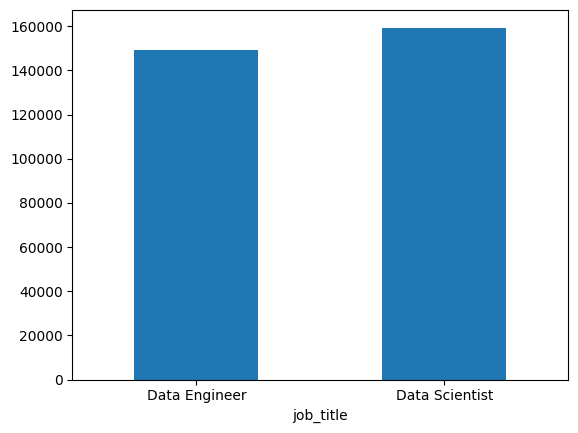

In [23]:
average_salaryUSD.plot(kind='bar')
plt.xticks(rotation=360);

In [24]:
df.head(3)

,work_year,experience_level,employment_nature,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Developer,168276,USD,168276,US,0,US,M
1,2024,MI,FT,Developer,112184,USD,112184,US,0,US,M
2,2024,EN,FT,Developer,180000,USD,180000,US,0,US,M


In [25]:
# 3. How many full-time employees based in the US work 100% remotely?
US_remote_ft_employees=df[df['employment_nature'].isin(['FT'])& df['employee_residence'].isin(['US'])& df['remote_ratio'].isin([100])]
count_of=len(US_remote_ft_employees)
print(f" The number of full-time employees based in the US and works 100% remotely is {count_of}")

 The number of full-time employees based in the US and works 100% remotely is 11125


### Level 2
1. Create a bar chart displaying the top 5 job titles with the highest average salary (in USD).
2. Compare the average salaries for employees working remotely 100%, 50%, and 0%. What patterns or trends do you observe?
3. Visualise the salary distribution (in USD) across company sizes (S, M, L). Which company size offers the highest average salary?

In [26]:
# Create a bar chart displaying the top 5 job titles with the highest average salary (in USD).
top5_jobs=df.groupby('job_title')['salary_in_usd'].mean().round(2).nlargest(n=5)
top5_jobs

job_title
Analytics Engineering Manager    399880.00
Data Science Tech Lead           375000.00
Applied AI ML Lead               292500.00
Head of Machine Learning         288701.00
Engineering Manager              262525.62
Name: salary_in_usd, dtype: float64

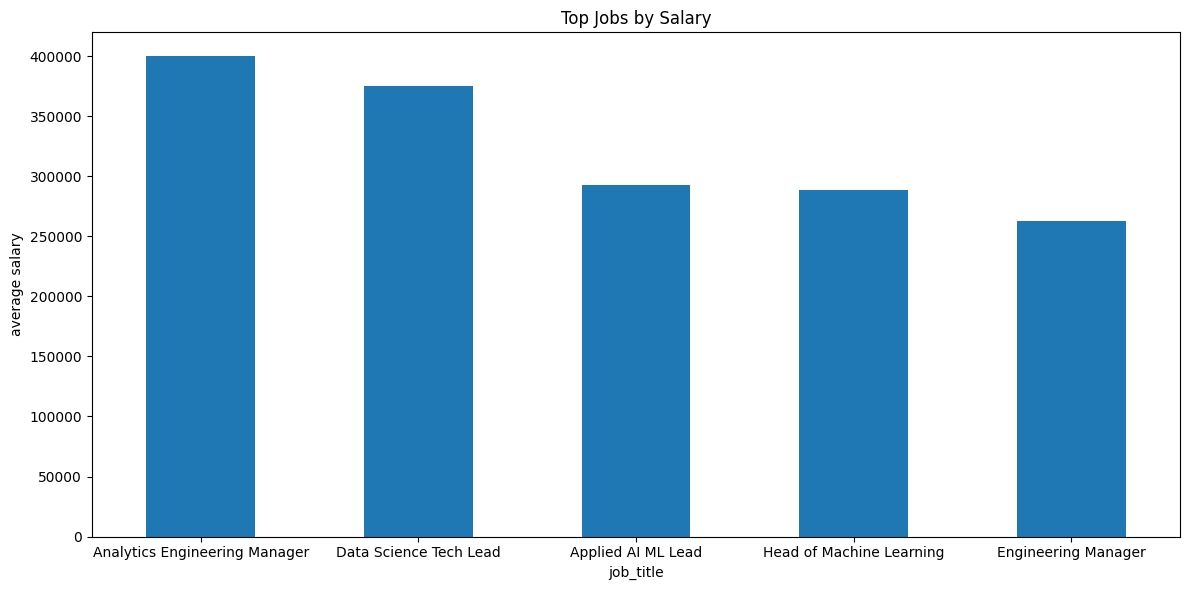

In [27]:
#Visualizing top Job titles
plt.figure(figsize=(12,6))
top5_jobs.plot(kind='bar')
plt.title('Top Jobs by Salary')
plt.ylabel('average salary')
plt.xticks(rotation=360)
plt.tight_layout();

In [28]:
#Checking remote ratios
df['remote_ratio'].value_counts()

remote_ratio
0      44355
100    12568
50       271
Name: count, dtype: int64

In [29]:
# Compare the average salaries for employees working remotely 100%, 50%, and 0%. What patterns or trends do you observe?
remote_filter=df[df['remote_ratio'].isin([100,50,0])]
remote_salaries=remote_filter.groupby('remote_ratio')['salary_in_usd'].mean().round(2)
remote_salaries

remote_ratio
0      162401.77
50      81866.87
100    149675.07
Name: salary_in_usd, dtype: float64

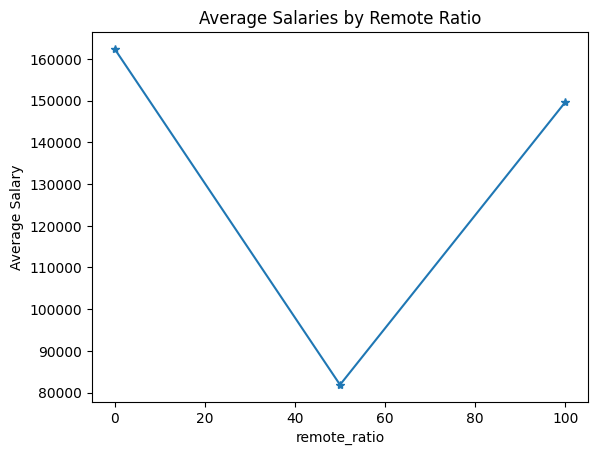

In [30]:
#Visualizing average salaries by remote ratio
remote_salaries.plot(kind='line',marker='*')
plt.ylabel('Average Salary')
plt.title('Average Salaries by Remote Ratio');

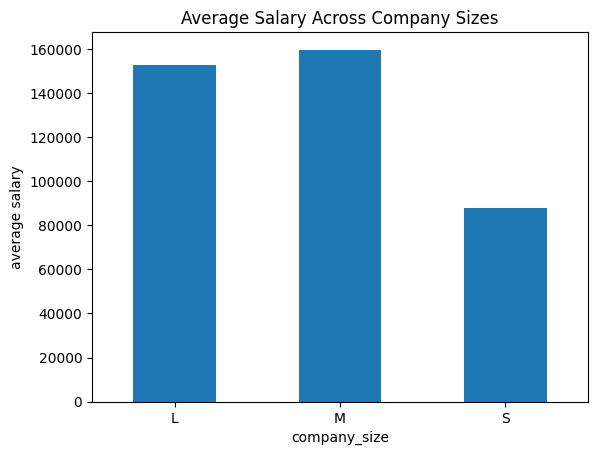

In [31]:
# Visualise the salary distribution (in USD) across company sizes (S, M, L). Which company size offers the highest average salary?
companysize_salary=df.groupby('company_size')['salary_in_usd'].mean().round(2)
companysize_salary.plot(kind='bar')
plt.xticks(rotation=360)
plt.ylabel('average salary')
plt.title('Average Salary Across Company Sizes');